<a href="https://colab.research.google.com/github/RoyalMaddy08/DARA_RSNN/blob/main/DARA_RSNN_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import random
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# ============================================================
# CONFIG -- the only cell you need to touch to swap datasets
# ============================================================
DATA_SOURCE = "csv"        # "synthetic" or "csv"
CSV_PATH = "/content/BE_battery_signals.csv"    # only used if DATA_SOURCE == "csv"

TARGET_COLUMN = "SOC_%"          # column the model predicts
TIME_COLUMN = "Time_s"           # excluded from features automatically (if present)
FEATURE_COLUMNS = None           # None = auto-detect; or e.g. ["Voltage_V","Current_A",...]

SEQ_LENGTH = 20                  # sliding window length (tune per sampling rate)

In [ ]:
def generate_synthetic_battery_data(seed=SEED, duration_s=3600*1.4, dt=1.0):
    rng = np.random.default_rng(seed)

    Q_NOMINAL_AH = 3.0
    V_MAX, V_MIN = 4.20, 3.00
    R0_REF, RP_REF, TAU_P = 0.045, 0.025, 40.0
    C_TH, H_CONV, T_AMBIENT = 55.0, 0.55, 25.0
    SOC0, T0 = 100.0, 25.0

    def ocv_from_soc(soc_pct):
        z = np.clip(soc_pct, 0, 100) / 100.0
        ocv = V_MIN + (V_MAX - V_MIN) * (1.10*z - 0.42*z**2 + 0.55*z**3 - 0.23*z**4)
        knee = 0.35 * np.exp(-z / 0.02)
        return np.clip(ocv - knee, V_MIN - 0.05, V_MAX + 0.02)

    def internal_resistance(soc_pct, temp_c):
        z = np.clip(soc_pct, 0.1, 100) / 100.0
        soc_factor = 1.0 + 0.9 * np.exp(-z / 0.06)
        temp_factor = np.clip(1.0 + 0.02 * (25.0 - temp_c), 0.6, 3.0)
        return R0_REF * soc_factor * temp_factor

    def current_profile(t):
        base = 1.0
        pulse = 0.8 * (np.sin(2*np.pi*t/180.0) > 0.6)
        heavy = 1.5 * (np.mod(t, 900) < 30)
        regen = -0.6 * (np.mod(t, 1200) < 15)
        return base + pulse + heavy + regen

    n_steps = int(duration_s / dt)
    time_s = np.arange(n_steps) * dt

    soc = np.zeros(n_steps); temp = np.zeros(n_steps)
    voltage = np.zeros(n_steps); current = np.zeros(n_steps)
    capacity_ah = np.zeros(n_steps); power_w = np.zeros(n_steps); energy_wh = np.zeros(n_steps)

    soc[0], temp[0] = SOC0, T0
    v_pol, fade = 0.0, 0.0

    for k in range(n_steps):
        t = time_s[k]
        I_cmd = current_profile(t)
        I = I_cmd + rng.normal(0, 0.01)
        q_usable = Q_NOMINAL_AH - fade
        capacity_ah[k] = max(q_usable * soc[k] / 100.0, 0.0)
        if soc[k] <= 0.2 and I_cmd > 0:
            I = 0.0
        current[k] = I

        r0 = internal_resistance(soc[k], temp[k])
        ocv = ocv_from_soc(soc[k])
        v_pol += (dt / TAU_P) * (I * RP_REF - v_pol)
        voltage[k] = ocv - I * r0 - v_pol + rng.normal(0, 0.003)

        q_gen = (I ** 2) * r0
        dT = (q_gen - H_CONV * (temp[k] - T_AMBIENT)) / C_TH

        power_w[k] = voltage[k] * current[k]
        energy_wh[k] = 0.0 if k == 0 else energy_wh[k-1] + power_w[k] * dt / 3600.0

        if k < n_steps - 1:
            soc_next = soc[k] - (I * dt) / (3600.0 * q_usable) * 100.0
            soc[k+1] = np.clip(soc_next, 0.0, 100.0)
            temp[k+1] = temp[k] + dT
            fade += abs(I) * dt / 3600.0 * 2e-5

    temp_series = temp + rng.normal(0, 0.01, size=n_steps)

    return pd.DataFrame({
        "Time_s": time_s,
        "Voltage_V": np.round(voltage, 4),
        "Current_A": np.round(current, 4),
        "Temp_C": np.round(temp_series, 3),
        "SOC_%": np.round(soc, 3),
        "Capacity_Ah": np.round(capacity_ah, 4),
        "Power_W": np.round(power_w, 4),
        "Energy_Wh": np.round(energy_wh, 5),
    })

In [3]:
if DATA_SOURCE == "synthetic":
    df = generate_synthetic_battery_data(seed=SEED)
elif DATA_SOURCE == "csv":
    df = pd.read_csv(CSV_PATH)
else:
    raise ValueError('DATA_SOURCE must be "synthetic" or "csv"')

# Basic cleanup -- harmless for synthetic data, important for real datasets
before = len(df)
df = df.dropna().reset_index(drop=True)
dropped = before - len(df)
if dropped > 0:
    print(f"Dropped {dropped} rows containing NaNs")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (5040, 8)

Columns: ['Time_s', 'Voltage_V', 'Current_A', 'Temp_C', 'SOC_%', 'Capacity_Ah', 'Power_W', 'Energy_Wh']


,Time_s,Voltage_V,Current_A,Temp_C,SOC_%,Capacity_Ah,Power_W,Energy_Wh
0,0.0,4.1101,1.9030,24.999,100.000,3.0000,7.8216,0.00000
1,1.0,4.1057,1.9094,24.987,99.982,2.9995,7.8394,0.00218
2,2.0,4.1096,1.9013,25.012,99.965,2.9989,7.8135,0.00435
3,3.0,4.1123,1.8915,25.023,99.947,2.9984,7.7783,0.00651
4,4.0,4.1114,1.9007,24.999,99.930,2.9979,7.8143,0.00868


In [4]:
# Resolve FEATURES / TARGET now that df is loaded -- works for any dataset
if FEATURE_COLUMNS is None:
    exclude = {TARGET_COLUMN}
    if TIME_COLUMN in df.columns:
        exclude.add(TIME_COLUMN)
    FEATURES = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
else:
    FEATURES = FEATURE_COLUMNS

TARGET = TARGET_COLUMN

assert TARGET in df.columns, f"TARGET_COLUMN '{TARGET}' not found in dataset columns: {df.columns.tolist()}"
assert len(FEATURES) > 0, "No feature columns resolved -- check FEATURE_COLUMNS / TARGET_COLUMN / TIME_COLUMN"

print("Features (%d):" % len(FEATURES), FEATURES)
print("Target:", TARGET)

Features (6): ['Voltage_V', 'Current_A', 'Temp_C', 'Capacity_Ah', 'Power_W', 'Energy_Wh']
Target: SOC_%


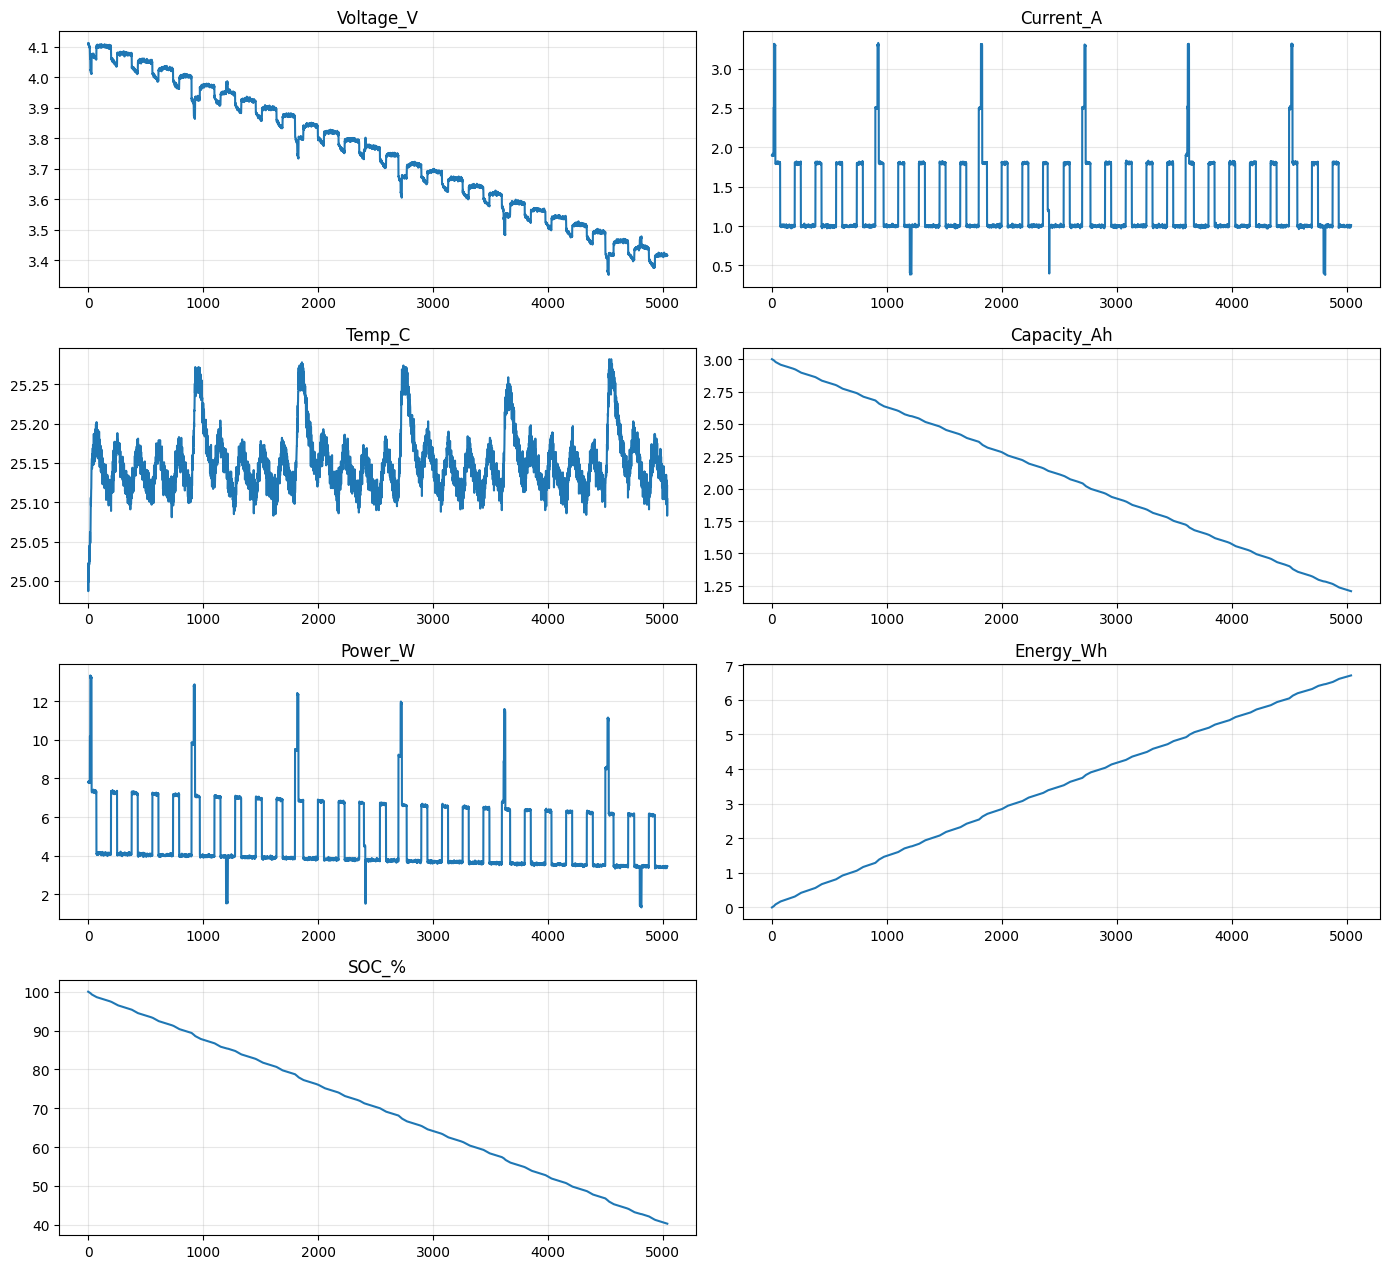

In [5]:
plot_cols = FEATURES[:6] + ([TARGET] if TARGET not in FEATURES else [])
n = len(plot_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, ax = plt.subplots(nrows, ncols, figsize=(14, 3.2*nrows))
ax = np.array(ax).reshape(-1)

x_axis = df[TIME_COLUMN] if TIME_COLUMN in df.columns else df.index

for i, col in enumerate(plot_cols):
    ax[i].plot(x_axis, df[col])
    ax[i].set_title(col)
    ax[i].grid(alpha=0.3)

for j in range(len(plot_cols), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.savefig("Demo_Signals_Overview.png", dpi=600, bbox_inches="tight")
plt.show()

In [6]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X = feature_scaler.fit_transform(df[FEATURES])
y = target_scaler.fit_transform(df[[TARGET]])   # keep 2D: shape (N,1)

print("X:", X.shape, " y:", y.shape)

X: (5040, 6)  y: (5040, 1)


In [7]:
X_seq, y_seq = [], []
for i in range(len(X) - SEQ_LENGTH):
    X_seq.append(X[i:i+SEQ_LENGTH])
    y_seq.append(y[i+SEQ_LENGTH])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)   # shape (N, 1)

print("X_seq:", X_seq.shape, " y_seq:", y_seq.shape)

X_seq: (5020, 20, 6)  y_seq: (5020, 1)


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.30, random_state=SEED, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, shuffle=True
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train target range:", y_train.min(), y_train.max())
print("Val   target range:", y_val.min(), y_val.max())
print("Test  target range:", y_test.min(), y_test.max())

Train: (3514, 20, 6)  Val: (753, 20, 6)  Test: (753, 20, 6)
Train target range: 0.0003013207894604353 0.9935216030266001
Val   target range: 0.005423774210288501 0.9894202922811657
Test  target range: 0.0 0.9878467281584278


In [9]:
batch_size = 64

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
    batch_size=batch_size, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
    batch_size=batch_size, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)),
    batch_size=batch_size, shuffle=False
)

print(len(train_loader), len(val_loader), len(test_loader))

55 12 12


In [10]:
# ============================================================
# Spike Encoder -- stochastic (Bernoulli) rate encoding
# ============================================================
class SpikeEncoder(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # x : (batch, sequence, features), values in [0,1]
        spikes = (x > torch.rand_like(x)).float()
        return spikes

In [11]:
# ============================================================
# Reservoir Layer -- FIXED
# Old version used a raw random 128x128 matrix with spectral
# radius ~11 (unstable / chaotic). This version normalizes the
# spectral radius to <1 (echo-state property) and adds leaky
# integration for better temporal memory.
#
# input_size is passed in explicitly so it always matches
# len(FEATURES), whatever dataset you load.
# ============================================================
class Reservoir(nn.Module):

    def __init__(self, input_size, reservoir_size=128,
                 spectral_radius=0.9, leak_rate=0.3,
                 input_scale=0.5, seed=SEED):
        super().__init__()

        gen = np.random.default_rng(seed)

        W_in = gen.normal(0, 1, size=(input_size, reservoir_size)) * input_scale

        W = gen.normal(0, 1, size=(reservoir_size, reservoir_size))
        radius = np.max(np.abs(np.linalg.eigvals(W)))
        W = (W / radius) * spectral_radius

        self.W_in = nn.Parameter(torch.tensor(W_in, dtype=torch.float32), requires_grad=False)
        self.W = nn.Parameter(torch.tensor(W, dtype=torch.float32), requires_grad=False)
        self.leak_rate = leak_rate

    def forward(self, spikes):
        batch, seq, _ = spikes.shape
        state = torch.zeros(batch, self.W.shape[0], device=spikes.device)
        outputs = []

        for t in range(seq):
            candidate = torch.tanh(spikes[:, t] @ self.W_in + state @ self.W)
            state = (1 - self.leak_rate) * state + self.leak_rate * candidate
            outputs.append(state)

        return torch.stack(outputs, dim=1)

In [12]:
# ============================================================
# Dual Adaptive Reservoir Attention (DARA)
# ============================================================
class DARA(nn.Module):

    def __init__(self, reservoir_size=128):
        super().__init__()

        self.temporal = nn.Sequential(
            nn.Linear(reservoir_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.neuron = nn.Sequential(
            nn.Linear(reservoir_size, reservoir_size),
            nn.Sigmoid()
        )

    def forward(self, reservoir):
        # reservoir : (batch, seq, reservoir_size)
        temporal_scores = self.temporal(reservoir)
        temporal_weights = torch.softmax(temporal_scores, dim=1)
        temporal_context = (temporal_weights * reservoir).sum(dim=1)

        neuron_weights = self.neuron(temporal_context)
        context = temporal_context * neuron_weights

        return context

In [13]:
# ============================================================
# Readout
# ============================================================
class Readout(nn.Module):

    def __init__(self, reservoir_size=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(reservoir_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.fc(x)

In [14]:
# ============================================================
# Full DARA-RSNN -- input_size comes from your dataset's FEATURES,
# so this works unchanged when you swap datasets tomorrow.
# ============================================================
class DARA_RSNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()
        self.encoder = SpikeEncoder()
        self.reservoir = Reservoir(input_size=input_size, spectral_radius=0.9, leak_rate=0.3)
        self.dara = DARA()
        self.readout = Readout()

    def forward(self, x):
        spikes = self.encoder(x)
        reservoir = self.reservoir(spikes)
        context = self.dara(reservoir)
        output = self.readout(context)
        return output

model = DARA_RSNN(input_size=len(FEATURES)).to(device)
print(model)

DARA_RSNN(
  (encoder): SpikeEncoder()
  (reservoir): Reservoir()
  (dara): DARA(
    (temporal): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
    (neuron): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Sigmoid()
    )
  )
  (readout): Readout(
    (fc): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=64, out_features=32, bias=True)
      (4): ReLU()
      (5): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


In [15]:
X_batch, _ = next(iter(test_loader))
X_batch = X_batch.to(device)

with torch.no_grad():
    spikes = model.encoder(X_batch)
    res_out = model.reservoir(spikes)

print("Reservoir output  min/max/mean:",
      res_out.min().item(), res_out.max().item(), res_out.mean().item())

diff = (res_out[0, -1] - res_out[1, -1]).abs().mean().item()
print("Mean abs difference between two different samples' final states:", diff)
print("(should be clearly non-trivial, e.g. > 0.05 -- if near 0, reservoir is still collapsing)")

Reservoir output  min/max/mean: -0.9879114627838135 0.9743449687957764 -0.014801442623138428
Mean abs difference between two different samples' final states: 0.20131100714206696
(should be clearly non-trivial, e.g. > 0.05 -- if near 0, reservoir is still collapsing)


In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

EPOCHS = 60
best_val_loss = float("inf")
train_history, val_history = [], []

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            val_running_loss += criterion(pred, y_batch).item()
    val_loss = val_running_loss / len(val_loader)

    scheduler.step(val_loss)
    train_history.append(train_loss)
    val_history.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "dara_rsnn_best.pt")

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train {train_loss:.6f} | Val {val_loss:.6f} "
              f"| LR {optimizer.param_groups[0]['lr']:.2e}")

print("\nBest val loss:", best_val_loss)
model.load_state_dict(torch.load("dara_rsnn_best.pt"))

Epoch 01/60 | Train 0.058877 | Val 0.004868 | LR 1.00e-03
Epoch 05/60 | Train 0.004621 | Val 0.003295 | LR 1.00e-03
Epoch 10/60 | Train 0.003878 | Val 0.002878 | LR 1.00e-03
Epoch 15/60 | Train 0.003513 | Val 0.002843 | LR 1.00e-03
Epoch 20/60 | Train 0.003661 | Val 0.004414 | LR 1.00e-03
Epoch 25/60 | Train 0.003428 | Val 0.004724 | LR 5.00e-04
Epoch 30/60 | Train 0.003474 | Val 0.003648 | LR 2.50e-04
Epoch 35/60 | Train 0.003209 | Val 0.003153 | LR 1.25e-04
Epoch 40/60 | Train 0.003161 | Val 0.004240 | LR 6.25e-05
Epoch 45/60 | Train 0.003258 | Val 0.003564 | LR 3.13e-05
Epoch 50/60 | Train 0.003137 | Val 0.004080 | LR 3.13e-05
Epoch 55/60 | Train 0.003252 | Val 0.004075 | LR 1.56e-05
Epoch 60/60 | Train 0.003201 | Val 0.004210 | LR 7.81e-06

Best val loss: 0.002843219437636435


<All keys matched successfully>

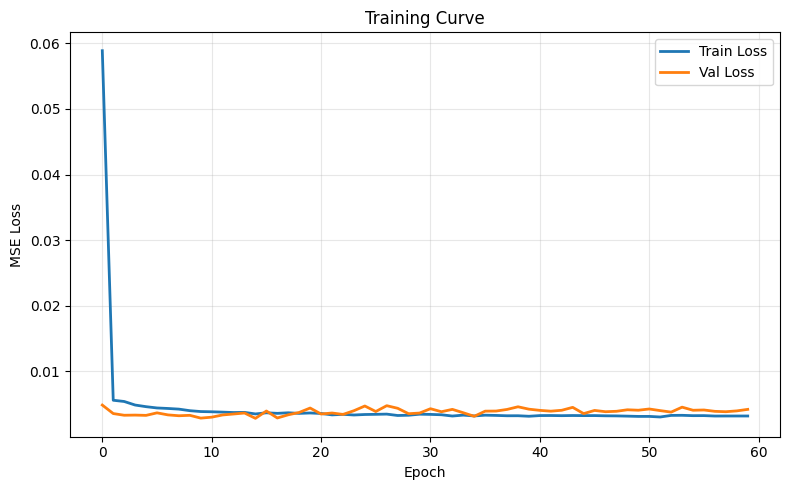

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="Train Loss", linewidth=2)
plt.plot(val_history, label="Val Loss", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Demo_Training_Curve.png", dpi=600, bbox_inches="tight")
plt.show()

In [18]:
model.eval()
predictions, targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        predictions.append(output.cpu().numpy())
        targets.append(y_batch.numpy())

predictions = np.vstack(predictions)
targets = np.vstack(targets)

predictions = target_scaler.inverse_transform(predictions)
targets = target_scaler.inverse_transform(targets)

rmse = np.sqrt(mean_squared_error(targets, predictions))
mae = mean_absolute_error(targets, predictions)
mape = np.mean(np.abs((targets - predictions) / (targets + 1e-8))) * 100
r2 = r2_score(targets, predictions)

print("="*40)
print(f"DARA-RSNN Performance -- target: {TARGET}")
print("="*40)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

DARA-RSNN Performance -- target: SOC_%
RMSE : 3.4373
MAE  : 2.7618
MAPE : 4.19%
R2   : 0.9605


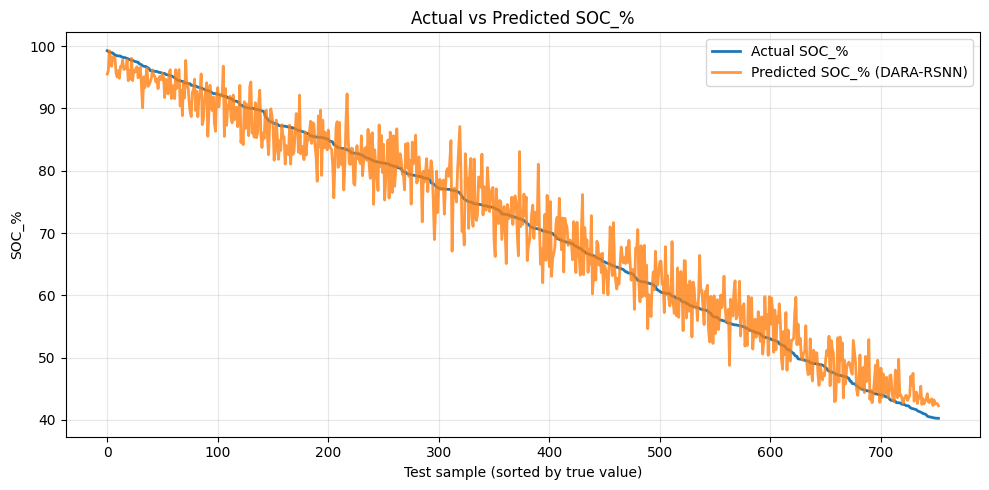

In [19]:
order = np.argsort(targets.flatten())[::-1]  # sort by true value for a clean curve

plt.figure(figsize=(10, 5))
plt.plot(targets[order], label=f"Actual {TARGET}", linewidth=2)
plt.plot(predictions[order], label=f"Predicted {TARGET} (DARA-RSNN)", linewidth=2, alpha=0.8)
plt.xlabel("Test sample (sorted by true value)")
plt.ylabel(TARGET)
plt.title(f"Actual vs Predicted {TARGET}")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Demo_Prediction.png", dpi=600, bbox_inches="tight")
plt.show()

In [20]:
def status_label(value):
    if value >= 60:
        return "Healthy"
    elif value >= 30:
        return "Aging / Monitor"
    else:
        return "Low Charge"

model.eval()
n_demo_steps = 15
start_idx = 100  # arbitrary starting point in the raw signal

header = f"{'Idx':>6} " + " ".join(f"{f[:10]:>10}" for f in FEATURES[:4]) + f" {'True':>9} {'Pred':>9}  Status"
print(header)
print("-" * len(header))

with torch.no_grad():
    for step in range(n_demo_steps):
        i = start_idx + step

        window_raw = df[FEATURES].iloc[i : i + SEQ_LENGTH].values
        window_scaled = feature_scaler.transform(window_raw)
        window_tensor = torch.FloatTensor(window_scaled).unsqueeze(0).to(device)

        pred_scaled = model(window_tensor).cpu().numpy()
        pred_val = target_scaler.inverse_transform(pred_scaled)[0, 0]

        true_val = df[TARGET].iloc[i + SEQ_LENGTH]
        row_vals = " ".join(f"{df[f].iloc[i + SEQ_LENGTH]:>10.3f}" for f in FEATURES[:4])

        print(f"{i + SEQ_LENGTH:>6} {row_vals} {true_val:>9.2f} {pred_val:>9.2f}  {status_label(pred_val)}")

   Idx  Voltage_V  Current_A     Temp_C Capacity_A      True      Pred  Status
------------------------------------------------------------------------------
   120      4.105      0.999     25.159      2.945     98.16     94.18  Healthy
   121      4.104      0.989     25.148      2.945     98.15     96.70  Healthy
   122      4.101      0.993     25.143      2.944     98.14     96.30  Healthy
   123      4.103      1.008     25.151      2.944     98.14     96.53  Healthy
   124      4.106      1.009     25.142      2.944     98.13     96.48  Healthy
   125      4.102      1.023     25.123      2.943     98.12     96.78  Healthy
   126      4.101      1.016     25.149      2.943     98.11     97.03  Healthy
   127      4.098      1.013     25.151      2.943     98.10     97.62  Healthy
   128      4.102      0.984     25.156      2.943     98.09     96.77  Healthy
   129      4.104      1.005     25.134      2.942     98.08     95.96  Healthy
   130      4.105      0.977     25.143   